# Product Rule

A guided notebook on the **Product Rule** for derivatives.

This notebook explains:

- why the product rule is needed
- the geometric intuition behind the rule
- a step-by-step derivation
- worked examples
- symbolic checks with SymPy
- Python visualizations
- practice exercises

This notebook follows the uploaded guidelines template.


## 1. Introduction

Sometimes a function is built as a **product** of two functions:

$$
y=f(t)=g(t)h(t)
$$

A common mistake is to think:

$$
(gh)'=g'h'
$$

This is **not correct**.

The correct rule is:

$$
(gh)'=g'h+gh'
$$

This is called the **Product Rule**.


## 2. Geometric Intuition

Think of the product

$$
f(t)=g(t)h(t)
$$

as the area of a rectangle:

- height: $g(t)$
- width: $h(t)$

So the area is:

$$
A=g(t)h(t)
$$

When $t$ changes by a small amount $\Delta t$, both dimensions change:

$$
g(t) \to g(t)+\Delta g(t)
$$

$$
h(t) \to h(t)+\Delta h(t)
$$

The new area is:

$$
[g(t)+\Delta g(t)][h(t)+\Delta h(t)]
$$


## 3. Expanding the New Area

Expand:

$$
[g(t)+\Delta g(t)][h(t)+\Delta h(t)]
$$

This gives:

$$
g(t)h(t)+g(t)\Delta h(t)+\Delta g(t)h(t)+\Delta g(t)\Delta h(t)
$$

The original area was:

$$
g(t)h(t)
$$

So the change in area is:

$$
\Delta f(t)
=
g(t)\Delta h(t)
+
\Delta g(t)h(t)
+
\Delta g(t)\Delta h(t)
$$


## 4. Derivation of the Product Rule

Start with:

$$
f(t)=g(t)h(t)
$$

The change in $f$ is:

$$
\Delta f(t)
=
g(t)\Delta h(t)
+
\Delta g(t)h(t)
+
\Delta g(t)\Delta h(t)
$$

Divide by $\Delta t$:

$$
\frac{\Delta f(t)}{\Delta t}
=
g(t)\frac{\Delta h(t)}{\Delta t}
+
h(t)\frac{\Delta g(t)}{\Delta t}
+
\frac{\Delta g(t)\Delta h(t)}{\Delta t}
$$

Now take the limit as $\Delta t\to0$.

The first two terms become:

$$
g(t)h'(t)
$$

and

$$
h(t)g'(t)
$$

The last term goes to zero.

Therefore:

$$
f'(t)=g'(t)h(t)+g(t)h'(t)
$$


## 5. Product Rule Formula

If

$$
f(t)=g(t)h(t)
$$

then

$$
f'(t)=g'(t)h(t)+g(t)h'(t)
$$

In words:

> derivative of the first times the second, plus the first times derivative of the second.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

## 6. Visualizing the Rectangle Idea

The original area is:

$$
g(t)h(t)
$$

The added pieces are:

$$
\Delta g(t)h(t), \qquad g(t)\Delta h(t), \qquad \Delta g(t)\Delta h(t)
$$


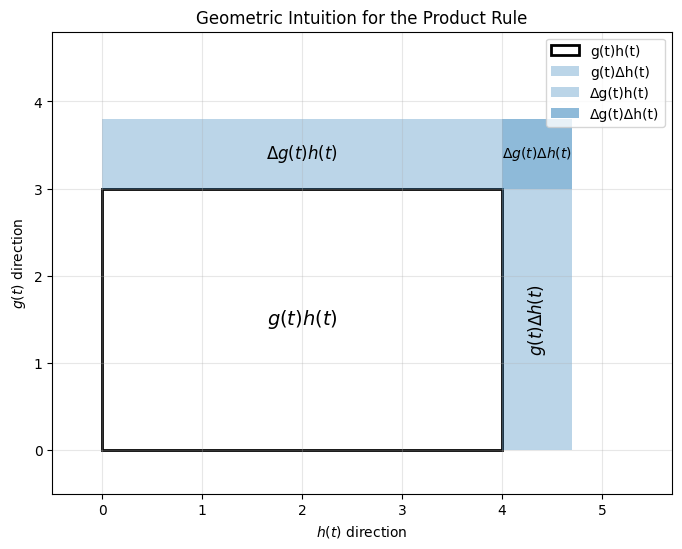

In [2]:
import matplotlib.patches as patches

g = 3.0
h = 4.0
delta_g = 0.8
delta_h = 0.7

plt.figure(figsize=(8,6))
ax = plt.gca()

original = patches.Rectangle((0, 0), h, g, fill=False, linewidth=2, label="g(t)h(t)")
right_strip = patches.Rectangle((h, 0), delta_h, g, alpha=0.3, label="g(t)Δh(t)")
top_strip = patches.Rectangle((0, g), h, delta_g, alpha=0.3, label="Δg(t)h(t)")
corner = patches.Rectangle((h, g), delta_h, delta_g, alpha=0.5, label="Δg(t)Δh(t)")

for patch in [original, right_strip, top_strip, corner]:
    ax.add_patch(patch)

plt.text(h/2, g/2, r"$g(t)h(t)$", ha="center", va="center", fontsize=14)
plt.text(h + delta_h/2, g/2, r"$g(t)\Delta h(t)$", ha="center", va="center", fontsize=12, rotation=90)
plt.text(h/2, g + delta_g/2, r"$\Delta g(t)h(t)$", ha="center", va="center", fontsize=12)
plt.text(h + delta_h/2, g + delta_g/2, r"$\Delta g(t)\Delta h(t)$", ha="center", va="center", fontsize=10)

plt.xlim(-0.5, h + delta_h + 1)
plt.ylim(-0.5, g + delta_g + 1)
plt.xlabel(r"$h(t)$ direction")
plt.ylabel(r"$g(t)$ direction")
plt.title("Geometric Intuition for the Product Rule")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.show()


## 7. Worked Example 1

Differentiate:

$$
y=t^2\sin t
$$

Let:

$$
g(t)=t^2
$$

and

$$
h(t)=\sin t
$$

Then:

$$
g'(t)=2t
$$

and

$$
h'(t)=\cos t
$$

Using the product rule:

$$
y'=g'(t)h(t)+g(t)h'(t)
$$

$$
y'=(2t)(\sin t)+(t^2)(\cos t)
$$

So:

$$
y'=2t\sin t+t^2\cos t
$$


## 8. Worked Example 2

Differentiate:

$$
y=e^t\ln t
$$

where $t>0$.

Let:

$$
g(t)=e^t
$$

and

$$
h(t)=\ln t
$$

Then:

$$
g'(t)=e^t
$$

and

$$
h'(t)=\frac1t
$$

Using the product rule:

$$
y'=e^t\ln t+e^t\frac1t
$$

Factor out $e^t$:

$$
y'=e^t\left(\ln t+\frac1t\right)
$$


## 9. Worked Example 3

Differentiate:

$$
y=(t+1)(t^3-2t)
$$

Let:

$$
g(t)=t+1
$$

and

$$
h(t)=t^3-2t
$$

Then:

$$
g'(t)=1
$$

and

$$
h'(t)=3t^2-2
$$

Using the product rule:

$$
y'=(1)(t^3-2t)+(t+1)(3t^2-2)
$$

Expand:

$$
y'=4t^3+3t^2-4t-2
$$


## 10. Symbolic Checks with SymPy

In [3]:
t = sp.symbols('t', positive=True)

examples = [
    t**2 * sp.sin(t),
    sp.exp(t) * sp.log(t),
    (t + 1) * (t**3 - 2*t)
]

for expr in examples:
    print("y =", expr)
    print("y' =", sp.simplify(sp.diff(expr, t)))
    print("-" * 80)


y = t**2*sin(t)
y' = t*(t*cos(t) + 2*sin(t))
--------------------------------------------------------------------------------
y = exp(t)*log(t)
y' = (t*log(t) + 1)*exp(t)/t
--------------------------------------------------------------------------------
y = (t + 1)*(t**3 - 2*t)
y' = 4*t**3 + 3*t**2 - 4*t - 2
--------------------------------------------------------------------------------


## 11. Python Visualization

Let:

$$
y=t^2\sin t
$$

The product rule gives:

$$
y'=2t\sin t+t^2\cos t
$$


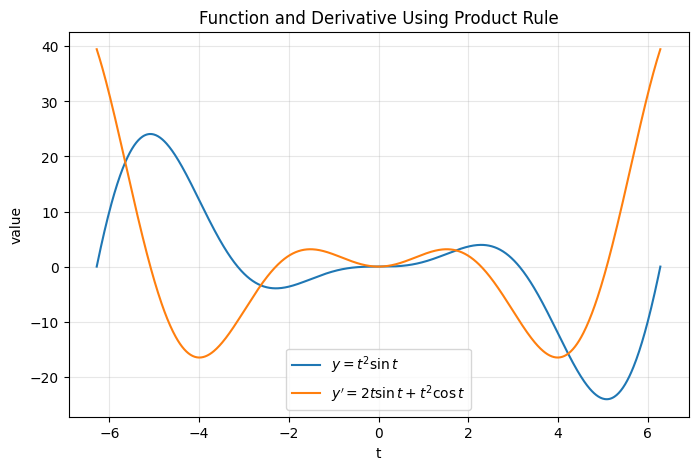

In [4]:
t_values = np.linspace(-2*np.pi, 2*np.pi, 800)

y = t_values**2 * np.sin(t_values)
dy = 2*t_values*np.sin(t_values) + t_values**2*np.cos(t_values)

plt.figure(figsize=(8,5))
plt.plot(t_values, y, label=r"$y=t^2\sin t$")
plt.plot(t_values, dy, label=r"$y'=2t\sin t+t^2\cos t$")
plt.title("Function and Derivative Using Product Rule")
plt.xlabel("t")
plt.ylabel("value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 12. Numerical Check

We can compare the product-rule derivative with a numerical derivative.


In [5]:
def numerical_derivative(func, x, h=1e-6):
    return (func(x + h) - func(x)) / h

def product_function(t):
    return t**2 * np.sin(t)

def product_rule_derivative(t):
    return 2*t*np.sin(t) + t**2*np.cos(t)

t0 = 1.5

print("Numerical derivative:", numerical_derivative(product_function, t0))
print("Product rule result :", product_rule_derivative(t0))


Numerical derivative: 3.151643750864963
Product rule result : 3.151643663564495


## 13. Common Mistake

The most common mistake is:

$$
(gh)'=g'h'
$$

This is wrong.

Example:

$$
y=t^2\sin t
$$

The wrong result would be:

$$
(2t)(\cos t)
$$

But the correct result is:

$$
2t\sin t+t^2\cos t
$$

The product rule accounts for the fact that **both factors change**.


## 14. Exercises

### Basic

1. Differentiate:

$$
y=t\cos t
$$

2. Differentiate:

$$
y=t^2e^t
$$

### Intermediate

3. Differentiate:

$$
y=(t^2+1)e^{3t}
$$

4. Differentiate:

$$
y=(2t-1)(t^2+3)
$$

### Advanced

5. Differentiate and simplify:

$$
y=\sin t\cos t
$$

6. Explain why the small term $\Delta g(t)\Delta h(t)$ disappears in the derivation.


## 15. Solutions / Checks

1.

$$
y'=\cos t-t\sin t
$$

2.

$$
y'=2t e^t+t^2e^t=e^t(2t+t^2)
$$

3.

$$
y'=2t e^{3t}+(t^2+1)3e^{3t}
$$

$$
y'=e^{3t}(3t^2+2t+3)
$$

4.

$$
y'=2(t^2+3)+(2t-1)(2t)
$$

$$
y'=6t^2-2t+6
$$

5.

$$
y'=\cos^2 t-\sin^2 t
$$

6. Since both $\Delta g(t)$ and $\Delta h(t)$ go to zero as $\Delta t\to0$, their product becomes negligible in the limit.


## 16. Conclusion

The product rule is used when differentiating a product of two functions.

If:

$$
f(t)=g(t)h(t)
$$

then:

$$
f'(t)=g'(t)h(t)+g(t)h'(t)
$$

Key intuition:

- the product can be viewed as rectangle area
- both dimensions change
- the total change has two main strips
- the tiny corner term disappears in the limit

This rule is essential for differentiating more complex functions.
